# Logistic Regression Robustness Analysis
### Chronological (out-of-time) validation, Leave-One-Month-Out CV, nested-CV tuning, and bootstrap confidence intervals

**Purpose.** This notebook responds to the reviewer's primary objection — that the original 80:20 *random* stratified split allows models to "see the future," since sessions from all twelve calendar months are mixed across train and test. It re-evaluates the **Logistic Regression** model (previously fit in `analysis.ipynb`) under two out-of-time protocols:

1. **Out-of-time (chronological) holdout** — train on the earlier months, test on the most recent months, reporting headline predictive metrics on a genuine future-facing holdout.
2. **Leave-One-Month-Out (LOMO) cross-validation** — each of the ten months present in the dataset is held out in turn; the model is refit on the remaining months, and both performance and the standardized-coefficient rank of `Month_Nov` are tracked per fold. This is the test that directly answers whether the November effect reported in the original manuscript persists across cohorts, rather than being an artifact of the random split.

Hyperparameters (`C`) are selected by an inner 5-fold grid search on the chronological training partition only (never touching the held-out months), following Fix 2 of the reviewer response plan. Bootstrap resampling of the chronological test set supplies 95% confidence intervals.

**This notebook does not modify or overwrite `analysis.ipynb`.** The original random-split Logistic Regression results remain the primary reported analysis; everything here is an additional robustness check, saved under distinct filenames (`lr_*`) so it cannot be confused with or silently replace the original outputs.

> Note on interpreting the chronological holdout coefficients: because the test months are excluded from training, `Month_Oct`/`Month_Nov`/`Month_Dec` are constant (zero-variance) columns during training, so their in-sample coefficients are uninformative by construction. The chronological split is reported for **aggregate predictive performance only**. Whether the `Month_Nov` effect itself is stable is answered by the LOMO analysis below, where Nov is only removed from training in the fold where it is the held-out target — in every other fold it remains available for the model to learn from.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, precision_score, recall_score,
    brier_score_loss, classification_report, confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Calendar order of the months actually present in this dataset.
# The UCI Online Shoppers Purchasing Intention dataset contains no
# January or April sessions, so the chronological sequence skips them.
MONTH_ORDER = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


In [30]:
# Load and encode exactly as in analysis.ipynb / XGboost.ipynb, so results
# remain directly comparable to the original models and to the RF/XGBoost
# robustness notebooks.
df = pd.read_csv("online_shoppers_intention.csv")

assert set(df["Month"].unique()) == set(MONTH_ORDER), \
    "MONTH_ORDER does not match the months present in the data - check for a schema change."

NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

y = df_encoded["Revenue"]
X = df_encoded.drop("Revenue", axis=1)

month_rank_map = {m: i for i, m in enumerate(MONTH_ORDER)}

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))


X shape: (12330, 68)
y distribution:
 Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


In [31]:
def evaluate_lr(model, X_te_s, y_te, label):
    """Standard metric bundle, matching the metrics already reported
    for Logistic Regression / Random Forest / XGBoost elsewhere in the project."""
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    return {
        "Split": label,
        "N_test": int(len(y_te)),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "ROC_AUC": round(roc_auc_score(y_te, y_prob), 4),
        "PR_AUC": round(average_precision_score(y_te, y_prob), 4),
        "F1": round(f1_score(y_te, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "Brier": round(brier_score_loss(y_te, y_prob), 4),
    }


## 1. Out-of-time (chronological) split

Train on the first seven calendar months present in the data (Feb-Sep); test on the final three months (Oct, Nov, Dec). Adjust `TEST_MONTHS` if a different train/test boundary is preferred for the manuscript (e.g. the final two months only).

In [32]:
TEST_MONTHS = ["Oct", "Nov", "Dec"]

train_mask = ~df["Month"].isin(TEST_MONTHS)
test_mask = df["Month"].isin(TEST_MONTHS)

X_train_chrono, X_test_chrono = X[train_mask], X[test_mask]
y_train_chrono, y_test_chrono = y[train_mask], y[test_mask]

train_months_present = sorted(df.loc[train_mask, "Month"].unique(), key=lambda m: month_rank_map[m])
print(f"Chronological split - train: {X_train_chrono.shape[0]} sessions, months: {train_months_present}")
print(f"Chronological split - test:  {X_test_chrono.shape[0]} sessions, months: {TEST_MONTHS}")


Chronological split - train: 7056 sessions, months: ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep']
Chronological split - test:  5274 sessions, months: ['Oct', 'Nov', 'Dec']


### 1.1 Hyperparameter tuning (inner 5-fold grid search, chronological training partition only)

In [33]:
scaler_chrono = StandardScaler()
X_train_chrono_s = scaler_chrono.fit_transform(X_train_chrono)
X_test_chrono_s = scaler_chrono.transform(X_test_chrono)

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=20000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="average_precision",   # inner-selection criterion: PR-AUC
    cv=inner_cv,
    n_jobs=-1,
)
grid_search.fit(X_train_chrono_s, y_train_chrono)

best_C = grid_search.best_params_["C"]
print("Selected C (inner 5-fold, scoring = PR-AUC):", best_C)

cv_grid_df = pd.DataFrame(grid_search.cv_results_)[
    ["param_C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")
cv_grid_df.to_csv("lr_gridsearch_chronological.csv", index=False)
cv_grid_df


Selected C (inner 5-fold, scoring = PR-AUC): 1


,param_C,mean_test_score,std_test_score,rank_test_score
3,1.000,0.676899,0.027000,1
4,10.000,0.676734,0.026898,2
5,100.000,0.676647,0.026895,3
6,1000.000,0.676637,0.026891,4
2,0.100,0.675896,0.027658,5
1,0.010,0.663612,0.029089,6
0,0.001,0.615322,0.032085,7


### 1.2 Evaluate the tuned model on the chronological holdout

In [34]:
lr_chrono = grid_search.best_estimator_

chrono_result = evaluate_lr(lr_chrono, X_test_chrono_s, y_test_chrono,
                             f"Chronological (train={train_months_present}, test={TEST_MONTHS})")
chrono_result["Selected_C"] = best_C
chrono_result_df = pd.DataFrame([chrono_result])
chrono_result_df.to_csv("lr_chronological_holdout_results.csv", index=False)
chrono_result_df


,Split,N_test,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,Selected_C
0,"Chronological (train=['Feb', 'Mar', 'May', 'Ju...",5274,0.8168,0.8323,0.6172,0.613,0.5023,0.5445,0.7012,0.1709,1


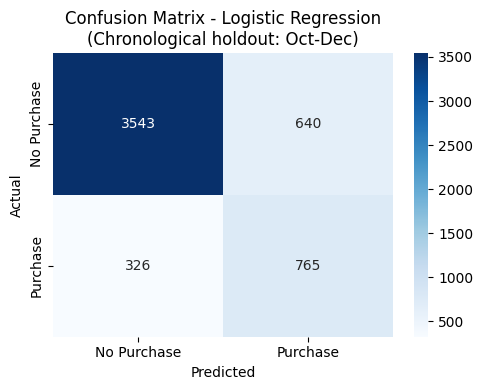

In [35]:
y_pred_chrono = lr_chrono.predict(X_test_chrono_s)
cm_chrono = confusion_matrix(y_test_chrono, y_pred_chrono)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_chrono, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression\n(Chronological holdout: Oct-Dec)")
plt.tight_layout()
plt.savefig("lr_confusion_matrix_chronological.png", dpi=200, bbox_inches="tight")
plt.show()


In [36]:
coef_table_chrono = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_chrono.coef_[0],
    "Odds_Ratio": np.exp(lr_chrono.coef_[0])
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_table_chrono["Rank"] = coef_table_chrono.index + 1
coef_table_chrono.to_csv("lr_chronological_coefficients.csv", index=False)

coef_table_chrono.head(15)


,Feature,Coefficient,Odds_Ratio,Rank
0,PageValues,2.918813,18.519292,1
1,ExitRates,-0.776169,0.460166,2
2,Month_May,-0.654641,0.519629,3
3,Month_Mar,-0.425878,0.653196,4
4,Month_Feb,-0.369112,0.691348,5
5,TrafficType_15,-0.236472,0.789408,6
6,BounceRates,-0.234009,0.791355,7
7,TrafficType_19,-0.175221,0.839271,8
8,TrafficType_5,0.158065,1.171243,9
9,Informational,0.146277,1.157516,10


## 2. Leave-One-Month-Out (LOMO) cross-validation

Each month is held out in turn; the model is refit on the remaining months (using the tuned `C` selected above), and evaluated on the held-out month. This is the protocol that answers the reviewer's question directly: **does the importance of `Month_Nov` persist in every monthly cohort, or is it an artifact of the original random split?**

In [37]:
months_present = df["Month"].unique().tolist()

lomo_results = []
lomo_coef_records = []

for held_out_month in MONTH_ORDER:
    if held_out_month not in months_present:
        continue

    train_mask_m = df["Month"] != held_out_month
    test_mask_m = df["Month"] == held_out_month

    X_train_m, X_test_m = X[train_mask_m], X[test_mask_m]
    y_train_m, y_test_m = y[train_mask_m], y[test_mask_m]

    scaler_m = StandardScaler()
    X_train_m_s = scaler_m.fit_transform(X_train_m)
    X_test_m_s = scaler_m.transform(X_test_m)

    lr_m = LogisticRegression(C=best_C, class_weight="balanced", max_iter=20000, random_state=RANDOM_STATE)
    lr_m.fit(X_train_m_s, y_train_m)

    row = evaluate_lr(lr_m, X_test_m_s, y_test_m, f"LOMO holdout: {held_out_month}")
    row["Held_out_month"] = held_out_month
    lomo_results.append(row)

    coef_m = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": lr_m.coef_[0],
        "Odds_Ratio": np.exp(lr_m.coef_[0])
    }).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)
    coef_m["Rank"] = coef_m.index + 1
    coef_m["Held_out_month"] = held_out_month
    lomo_coef_records.append(coef_m)

lomo_results_df = pd.DataFrame(lomo_results)
lomo_results_df = lomo_results_df[["Held_out_month"] + [c for c in lomo_results_df.columns if c != "Held_out_month"]]
lomo_results_df.to_csv("lr_lomo_results.csv", index=False)
lomo_results_df


,Held_out_month,Split,N_test,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier
0,Feb,LOMO holdout: Feb,184,0.9837,0.9853,0.4111,0.6667,0.7012,0.5000,1.0000,0.0597
1,Mar,LOMO holdout: Mar,1907,0.9271,0.9656,0.7507,0.7098,0.6877,0.5923,0.8854,0.1049
2,May,LOMO holdout: May,3364,0.7554,0.9191,0.6362,0.4488,0.4304,0.2970,0.9178,0.1780
3,June,LOMO holdout: June,288,0.8368,0.8333,0.4311,0.4198,0.3529,0.3269,0.5862,0.1296
4,Jul,LOMO holdout: Jul,432,0.8264,0.8064,0.4962,0.4966,0.3972,0.4458,0.5606,0.1514
5,Aug,LOMO holdout: Aug,433,0.8476,0.8675,0.6471,0.5823,0.4898,0.5610,0.6053,0.1263
6,Sep,LOMO holdout: Sep,448,0.7991,0.7619,0.5516,0.5408,0.4198,0.4818,0.6163,0.1850
7,Oct,LOMO holdout: Oct,549,0.8179,0.8607,0.6822,0.6479,0.5489,0.5444,0.8000,0.1685
8,Nov,LOMO holdout: Nov,2998,0.8005,0.8216,0.6392,0.6304,0.4962,0.5944,0.6711,0.1727
9,Dec,LOMO holdout: Dec,1727,0.8645,0.8753,0.5902,0.5880,0.5343,0.4744,0.7731,0.1457


In [38]:
print("LOMO performance summary (mean across the", len(lomo_results_df), "held-out months):")
lomo_summary = lomo_results_df[["Accuracy", "ROC_AUC", "PR_AUC", "F1", "MCC", "Precision", "Recall", "Brier"]].agg(["mean", "std"])
lomo_summary.to_csv("lr_lomo_performance_summary.csv")
lomo_summary


LOMO performance summary (mean across the 10 held-out months):


,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier
mean,0.845900,0.869670,0.583560,0.573110,0.505840,0.48180,0.741580,0.142180
std,0.066349,0.070225,0.110178,0.095731,0.116686,0.10269,0.156012,0.038646


In [39]:
lomo_coefs_all = pd.concat(lomo_coef_records, ignore_index=True)
lomo_coefs_all.to_csv("lr_lomo_coefficients_all_months.csv", index=False)

# Month_Nov's rank in every fold EXCEPT the fold where Nov itself is the held-out
# month (in that one fold, Month_Nov is absent from training and therefore
# uninformative by construction, exactly as with the chronological split above).
nov_rank_by_fold = lomo_coefs_all[lomo_coefs_all["Feature"] == "Month_Nov"][
    ["Held_out_month", "Rank", "Coefficient", "Odds_Ratio"]
].reset_index(drop=True)
nov_rank_by_fold.to_csv("lr_lomo_month_nov_rank_by_fold.csv", index=False)

print("Month_Nov rank across LOMO folds (rank 1 = most important |standardized coefficient|):")
nov_rank_by_fold


Month_Nov rank across LOMO folds (rank 1 = most important |standardized coefficient|):


,Held_out_month,Rank,Coefficient,Odds_Ratio
0,Feb,6,0.228399,1.256586
1,Mar,6,0.240057,1.271322
2,May,6,0.210994,1.234905
3,June,6,0.230394,1.259095
4,Jul,6,0.221093,1.247440
5,Aug,3,0.388715,1.475084
6,Sep,7,0.228808,1.257101
7,Oct,5,0.242119,1.273946
8,Nov,68,0.000000,1.000000
9,Dec,7,0.233551,1.263077


In [40]:
nov_rank_valid = nov_rank_by_fold[nov_rank_by_fold["Held_out_month"] != "Nov"]
print(f"Month_Nov mean rank across the {len(nov_rank_valid)} LOMO folds where Nov remained in training: "
      f"{nov_rank_valid['Rank'].mean():.2f} (SD {nov_rank_valid['Rank'].std():.2f})")
print(f"Month_Nov mean |coefficient|: {nov_rank_valid['Coefficient'].abs().mean():.4f} "
      f"(SD {nov_rank_valid['Coefficient'].abs().std():.4f})")


Month_Nov mean rank across the 9 LOMO folds where Nov remained in training: 5.78 (SD 1.20)
Month_Nov mean |coefficient|: 0.2471 (SD 0.0539)


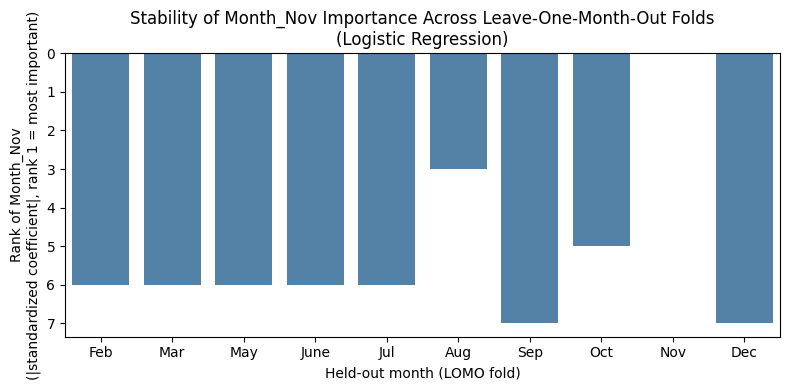

In [41]:
plot_df = nov_rank_valid.copy()
plot_df["Held_out_month"] = pd.Categorical(plot_df["Held_out_month"], categories=MONTH_ORDER, ordered=True)
plot_df = plot_df.sort_values("Held_out_month")

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="Held_out_month", y="Rank", color="steelblue")
plt.gca().invert_yaxis()
plt.ylabel("Rank of Month_Nov\n(|standardized coefficient|, rank 1 = most important)")
plt.xlabel("Held-out month (LOMO fold)")
plt.title("Stability of Month_Nov Importance Across Leave-One-Month-Out Folds\n(Logistic Regression)")
plt.tight_layout()
plt.savefig("lr_lomo_month_nov_rank_stability.png", dpi=200, bbox_inches="tight")
plt.show()


In [42]:
# RBO@k for LOMO coefficient rankings — top-k stability, not just full-rank correlation
def rbo(list1, list2, p=0.9):
    s, l = (list1, list2) if len(list1) <= len(list2) else (list2, list1)
    short_len, long_len = len(s), len(l)
    if short_len == 0:
        return 0.0
    x_k = 0
    rbo_sum = 0.0
    s_set, l_set = set(), set()
    for d in range(1, long_len + 1):
        if d <= short_len:
            s_set.add(s[d - 1])
        l_set.add(l[d - 1])
        x_k = len(s_set & l_set)
        rbo_sum += (p ** (d - 1)) * (x_k / d)
    rbo_ext = (1 - p) * rbo_sum
    if short_len < long_len:
        x_s = len(s_set & l_set)
        rbo_ext += (x_s * (1 - p) / short_len) * (p ** short_len) * (long_len - short_len) / long_len \
                   if short_len > 0 else 0
    return min(rbo_ext, 1.0)

def rbo_at_k(rank_df_a, rank_df_b, feature_col="feature", rank_col="rank", ks=(5, 10, None), p=0.9):
    order_a = rank_df_a.sort_values(rank_col)[feature_col].tolist()
    order_b = rank_df_b.sort_values(rank_col)[feature_col].tolist()
    rows = []
    for k in ks:
        la = order_a[:k] if k else order_a
        lb = order_b[:k] if k else order_b
        rows.append({"top_k": k if k else "all", "RBO": round(rbo(la, lb, p=p), 4), "p": p})
    return pd.DataFrame(rows)

# Compare each LOMO fold's coefficient ranking against LR's full-data chronological ranking
lr_chrono_ranking = coef_table_chrono.rename(columns={"Feature": "feature", "Rank": "rank"})

rbo_rows = []
for fold_month in lomo_coefs_all["Held_out_month"].unique():
    fold_rank = lomo_coefs_all[lomo_coefs_all["Held_out_month"] == fold_month] \
                    .rename(columns={"Feature": "feature", "Rank": "rank"})
    fold_scores = rbo_at_k(fold_rank, lr_chrono_ranking, ks=(5, 10, None))
    fold_scores["Held_out_month"] = fold_month
    rbo_rows.append(fold_scores)

lr_lomo_rbo = pd.concat(rbo_rows, ignore_index=True)
lr_lomo_rbo.to_csv("lr_lomo_rbo_at_10.csv", index=False)
lr_lomo_rbo

,top_k,RBO,p,Held_out_month
0,5,0.3964,0.9,Feb
1,10,0.5469,0.9,Feb
2,all,0.7541,0.9,Feb
3,5,0.3650,0.9,Mar
4,10,0.5194,0.9,Mar
5,all,0.7433,0.9,Mar
6,5,0.3512,0.9,May
7,10,0.4941,0.9,May
8,all,0.6577,0.9,May
9,5,0.3964,0.9,June


## 3. Bootstrap confidence intervals on the chronological holdout

1,000 bootstrap resamples of the chronological (Oct-Dec) test predictions, giving non-parametric 95% CIs for the headline metrics - the same style of evidence already reported for the repeated-CV results in `repeated_cv_summary.csv`.

In [43]:
N_BOOTSTRAPS = 1000
rng = np.random.default_rng(RANDOM_STATE)

y_test_arr = y_test_chrono.to_numpy()
y_prob_chrono = lr_chrono.predict_proba(X_test_chrono_s)[:, 1]
y_pred_chrono_arr = lr_chrono.predict(X_test_chrono_s)

boot_metrics = {"ROC_AUC": [], "PR_AUC": [], "F1": [], "MCC": []}
n = len(y_test_arr)

for _ in range(N_BOOTSTRAPS):
    idx = rng.integers(0, n, n)
    yt, yp, ypb = y_test_arr[idx], y_pred_chrono_arr[idx], y_prob_chrono[idx]
    if len(np.unique(yt)) < 2:
        continue
    boot_metrics["ROC_AUC"].append(roc_auc_score(yt, ypb))
    boot_metrics["PR_AUC"].append(average_precision_score(yt, ypb))
    boot_metrics["F1"].append(f1_score(yt, yp))
    boot_metrics["MCC"].append(matthews_corrcoef(yt, yp))

boot_summary = []
for metric, vals in boot_metrics.items():
    vals = np.array(vals)
    boot_summary.append({
        "Metric": metric,
        "Mean": round(vals.mean(), 4),
        "Std": round(vals.std(), 4),
        "CI95_low": round(np.percentile(vals, 2.5), 4),
        "CI95_high": round(np.percentile(vals, 97.5), 4),
        "N_bootstraps": len(vals),
    })

boot_summary_df = pd.DataFrame(boot_summary)
boot_summary_df.to_csv("lr_chronological_bootstrap_ci.csv", index=False)
boot_summary_df


,Metric,Mean,Std,CI95_low,CI95_high,N_bootstraps
0,ROC_AUC,0.8321,0.0075,0.8170,0.8458,1000
1,PR_AUC,0.6179,0.0162,0.5839,0.6487,1000
2,F1,0.6133,0.0116,0.5912,0.6352,1000
3,MCC,0.5026,0.0140,0.4759,0.5286,1000


In [44]:
joblib.dump(lr_chrono, "shopping_model_lr_chronological.pkl")
joblib.dump(scaler_chrono, "shopping_scaler_lr_chronological.pkl")

print("Saved outputs:")
print(" - lr_gridsearch_chronological.csv           (inner 5-fold grid search results)")
print(" - lr_chronological_holdout_results.csv      (headline metrics, Oct-Dec holdout)")
print(" - lr_chronological_coefficients.csv         (standardized coefficients, chronological model)")
print(" - lr_confusion_matrix_chronological.png")
print(" - lr_lomo_results.csv                       (per-month LOMO performance)")
print(" - lr_lomo_performance_summary.csv           (mean/SD across LOMO folds)")
print(" - lr_lomo_coefficients_all_months.csv       (full coefficient table, every LOMO fold)")
print(" - lr_lomo_month_nov_rank_by_fold.csv        (Month_Nov rank/coefficient per LOMO fold)")
print(" - lr_lomo_month_nov_rank_stability.png")
print(" - lr_chronological_bootstrap_ci.csv         (1,000-resample 95% CIs)")
print(" - shopping_model_lr_chronological.pkl, shopping_scaler_lr_chronological.pkl")


Saved outputs:
 - lr_gridsearch_chronological.csv           (inner 5-fold grid search results)
 - lr_chronological_holdout_results.csv      (headline metrics, Oct-Dec holdout)
 - lr_chronological_coefficients.csv         (standardized coefficients, chronological model)
 - lr_confusion_matrix_chronological.png
 - lr_lomo_results.csv                       (per-month LOMO performance)
 - lr_lomo_performance_summary.csv           (mean/SD across LOMO folds)
 - lr_lomo_coefficients_all_months.csv       (full coefficient table, every LOMO fold)
 - lr_lomo_month_nov_rank_by_fold.csv        (Month_Nov rank/coefficient per LOMO fold)
 - lr_lomo_month_nov_rank_stability.png
 - lr_chronological_bootstrap_ci.csv         (1,000-resample 95% CIs)
 - shopping_model_lr_chronological.pkl, shopping_scaler_lr_chronological.pkl
